In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

df.head()

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 30)

In [4]:
drop_cols = [
    "CustomerID",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]
X_cluster = df.drop(columns=drop_cols).copy()
X_cluster.shape

(7043, 19)

In [5]:
numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_cluster.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X_cluster)

print(X_processed.shape)

(7043, 46)


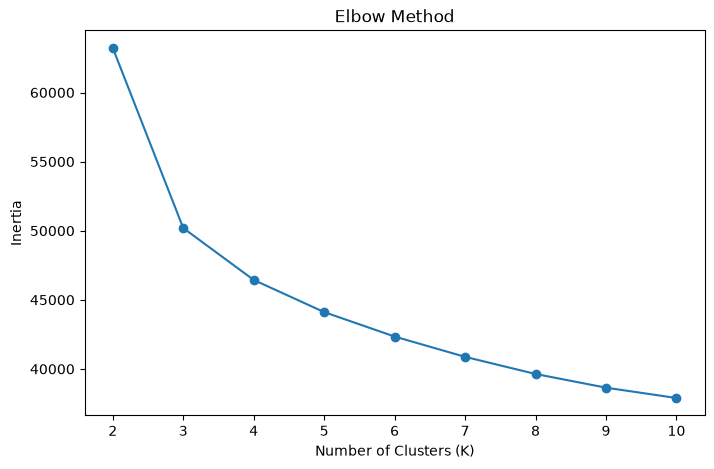

In [7]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.show()

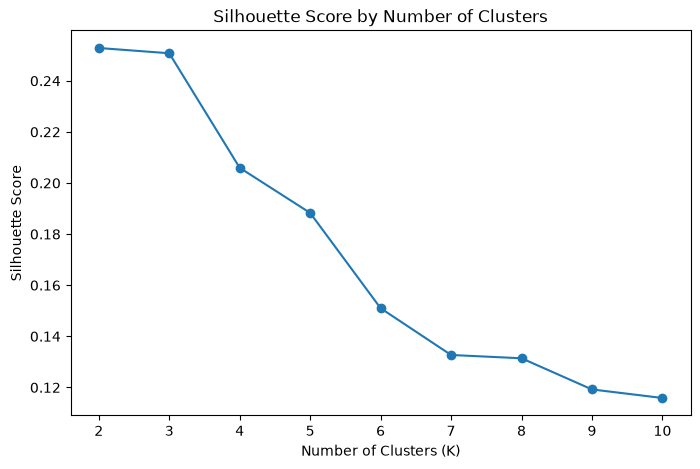

In [8]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_processed)
    
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(K_range)
plt.show()

In [9]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_processed)

df["Cluster"] = cluster_labels

df["Cluster"].value_counts().sort_index()

Cluster
0    3192
1    1526
2    2325
Name: count, dtype: int64

In [10]:
cluster_profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Tenure=("Tenure Months", "mean"),
    Avg_Monthly_Charges=("Monthly Charges", "mean"),
    Avg_Total_Charges=("Total Charges", "mean"),
    Avg_CLTV=("CLTV", "mean"),
    Churn_Rate=("Churn Value", "mean")
).round(2)

cluster_profile

,Customers,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Avg_CLTV,Churn_Rate
Cluster,,,,,,
0,3192,15.31,67.88,1019.22,4047.74,0.44
1,1526,30.55,21.08,662.60,4374.38,0.07
2,2325,56.99,89.15,5071.69,4901.32,0.15


In [11]:
for col in ["Contract", "Internet Service", "Payment Method"]:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df["Cluster"],
            df[col],
            normalize="index"
        ).round(3)
    )


--- Contract ---
Contract  Month-to-month  One year  Two year
Cluster                                     
0                  0.869     0.106     0.024
1                  0.343     0.239     0.418
2                  0.248     0.331     0.421

--- Internet Service ---
Internet Service    DSL  Fiber optic   No
Cluster                                  
0                 0.477        0.523  0.0
1                 0.000        0.000  1.0
2                 0.387        0.613  0.0

--- Payment Method ---
Payment Method  Bank transfer (automatic)  Credit card (automatic)  \
Cluster                                                              
0                                   0.145                    0.148   
1                                   0.218                    0.217   
2                                   0.323                    0.309   

Payment Method  Electronic check  Mailed check  
Cluster                                         
0                          0.492         0.215  

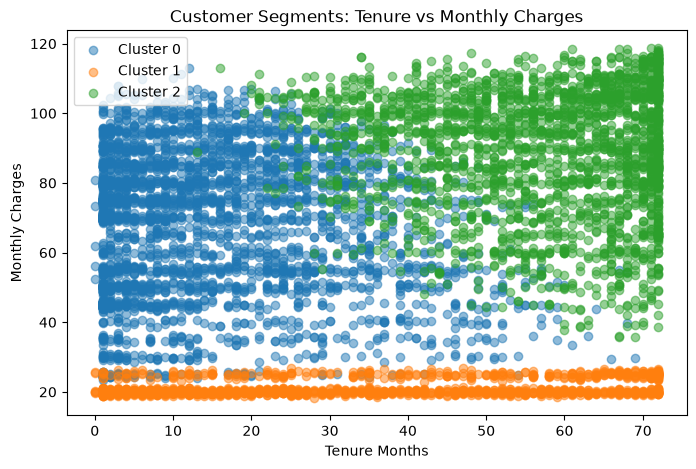

In [12]:
plt.figure(figsize=(8, 5))

for cluster in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Tenure Months"],
        cluster_data["Monthly Charges"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Tenure Months")
plt.ylabel("Monthly Charges")
plt.title("Customer Segments: Tenure vs Monthly Charges")
plt.legend()
plt.show()

In [13]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_processed)

df["DBSCAN_Cluster"] = dbscan_labels

print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1    3283
 0     410
 1    1578
 2    1496
 3     130
 4       6
 5     135
 6       5
Name: count, dtype: int64


In [14]:
mask = df["DBSCAN_Cluster"] != -1

if df.loc[mask, "DBSCAN_Cluster"].nunique() > 1:
    dbscan_silhouette = silhouette_score(
        X_processed[mask],
        df.loc[mask, "DBSCAN_Cluster"]
    )
    
    print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
    print("DBSCAN did not produce enough clusters for silhouette evaluation.")

DBSCAN Silhouette Score: 0.15332308583045898


In [15]:
# import joblib

# joblib.dump(
#     final_kmeans,
#     "../models/kmeans_customer_segmentation.pkl"
# )

# joblib.dump(
#     preprocessor,
#     "../models/clustering_preprocessor.pkl"
# )

# print("Final K-Means model and preprocessor saved successfully.")

# Clustering Summary

## Objective

The objective of the clustering analysis was to segment customers into meaningful groups based on their demographic characteristics, subscribed services, contract information, payment methods, tenure, and spending behavior.

## Features

The clustering model used customer characteristics including:

- Demographic information
- Service subscriptions
- Contract type
- Payment method
- Tenure
- Monthly Charges
- Total Charges

The following target-related or outcome-related variables were excluded from the clustering features:

- `Churn Label`
- `Churn Value`
- `Churn Score`
- `Churn Reason`
- `CLTV`

Identifiers and high-cardinality location-related features were also excluded.

## Preprocessing

- Numerical features were standardized using `StandardScaler`.
- Categorical features were transformed using `OneHotEncoder(handle_unknown="ignore")`.
- The resulting processed dataset contained 46 features.

## Cluster Selection

The Elbow Method and Silhouette Score were used to evaluate different numbers of clusters.

The Silhouette Scores for the main candidate values were:

- K=2: 0.253
- K=3: 0.251

K=2 achieved a slightly higher Silhouette Score. However, K=3 produced more differentiated and interpretable customer segments.

With K=3, the analysis separated customers into:

1. Newer / Higher-Risk Internet Customers
2. Basic / Non-Internet Customers
3. Long-Tenure / Higher-Value Customers

Therefore, K=3 was selected as the final segmentation approach for business-oriented customer profiling.

## Final Customer Segments

### Cluster 0 — Newer / Higher-Risk Internet Customers

- 3,192 customers
- Average Tenure: 15.31 months
- Average Monthly Charges: 67.88
- Average Total Charges: 1,019.22
- Observed churn rate: 44%
- 86.9% have month-to-month contracts
- 49.2% use electronic check
- 47.7% use DSL Internet
- 52.3% use Fiber optic Internet

This segment contains relatively newer customers with moderate monthly spending and a high observed churn rate.

### Cluster 1 — Basic / Non-Internet Customers

- 1,526 customers
- Average Tenure: 30.55 months
- Average Monthly Charges: 21.08
- Average Total Charges: 662.60
- Observed churn rate: 7%
- 100% have no Internet service
- 41.8% have two-year contracts
- 48.6% use mailed check

This segment is characterized by low monthly spending and customers without Internet service.

### Cluster 2 — Long-Tenure / Higher-Value Customers

- 2,325 customers
- Average Tenure: 56.99 months
- Average Monthly Charges: 89.15
- Average Total Charges: 5,071.69
- Average CLTV: 4,901.32
- Observed churn rate: 15%
- 42.1% have two-year contracts
- 61.3% use Fiber optic Internet
- 32.3% use automatic bank transfer
- 30.9% use automatic credit card payment

This segment contains customers with substantially longer tenure, higher monthly spending, and higher accumulated charges.

## Churn Profiling

Churn was not used as an input feature when creating the clusters.

Instead, churn was analyzed after clustering to understand the characteristics of each resulting customer segment.

The observed churn rates were:

- Cluster 0: 44%
- Cluster 1: 7%
- Cluster 2: 15%

This profiling provides additional insight into the behavioral differences between the customer segments without introducing churn information into the clustering process.

## Visualization Insights

The Tenure vs Monthly Charges visualization shows clear differences between the three customer segments.

- Cluster 1 is concentrated at very low monthly charges.
- Cluster 0 is mainly associated with shorter tenure and moderate monthly charges.
- Cluster 2 contains customers with longer tenure and generally higher monthly charges.

The visualization supports the differences observed in the numerical cluster profiles.

## DBSCAN Comparison

DBSCAN was also evaluated as an alternative clustering algorithm.

- DBSCAN Silhouette Score: 0.153
- 3,283 customers were classified as noise.
- Several resulting clusters were very small.

The resulting segmentation was therefore less practical and less interpretable for this dataset compared with the final K-Means solution.

## Final Model

K-Means with 3 clusters was selected as the final customer segmentation model.

The final K-Means model and preprocessing pipeline were saved for future use in the Streamlit application.

In [17]:
preprocessor.feature_names_in_

array(['Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges'], dtype=object)